# TDA: Define landmark → witness pairs using muspan package

You have 3 cell types: epithelial_tumor (ET), mesenchymal_tumor (MT), and fibroblast (F)

| Landmark | Witness | Biological meaning                                             |
| -------- | ------- | -------------------------------------------------------------- |
| ET       | MT      | How mesenchymal tumor cells arrange around epithelial clusters |
| ET       | F       | How fibroblasts surround epithelial clusters                   |
| MT       | ET      | How epithelial cells arrange around mesenchymal clusters       |
| MT       | F       | Fibroblast interactions with mesenchymal clusters              |
| F        | ET      | Tumor infiltration by fibroblasts?                             |
| F        | MT      | Fibroblast-mesenchymal tumor interactions                      |


In [1]:
from uq_physicell.database.ma_db import load_samples
from uq_physicell.model_analysis.utils import mcds_list_to_qoi_df_long
from uq_physicell.utils.sumstats import recreate_qoi_functions
import os
import pandas as pd

db_file = 'uq_Simulations_OAT_CoCulture.db'
qoi_funcs = {  # first element of tuple is summary stats of PH
    'ET_MT_landmark_witness_pair': lambda df: qoi_func_relational_ph(df, 'epithelial_tumor', 'mesenchymal_tumor')[0],
    'ET_F_landmark_witness_pair': lambda df: qoi_func_relational_ph(df, 'epithelial_tumor', 'fibroblast')[0],
    'MT_ET_landmark_witness_pair': lambda df: qoi_func_relational_ph(df, 'mesenchymal_tumor', 'epithelial_tumor')[0],
    'MT_F_landmark_witness_pair': lambda df: qoi_func_relational_ph(df, 'mesenchymal_tumor', 'fibroblast')[0],
    'F_ET_landmark_witness_pair': lambda df: qoi_func_relational_ph(df, 'fibroblast', 'epithelial_tumor')[0],
    'F_MT_landmark_witness_pair': lambda df: qoi_func_relational_ph(df, 'fibroblast', 'mesenchymal_tumor')[0],
}
chunk_size = 10
dic_parameters = load_samples(db_file)
all_sample_ids = list(dic_parameters.keys())
df_tda_file = 'TDA_DowkerWitness.parquet'
if os.path.exists(df_tda_file):
    df_tda = pd.read_parquet(df_tda_file)
else:
    df_tda = mcds_list_to_qoi_df_long(recreate_qoi_functions(qoi_funcs), all_sample_ids, chunk_size, db_file)
    # Columns containing the PH summary stats have names ending with '_landmark_witness_pair'
    columns = [col for col in df_tda.columns if col.endswith('_landmark_witness_pair')]
    # Extract feature names from the first non-empty row of the first relevant column
    for row in df_tda[columns[0]]:
        if isinstance(row, pd.Series):
            features_ph = list(row.index)
            break
    # Reshape the DataFrame with a column for each PH summary stats
    for col in columns:
        for feature in features_ph:
            df_tda[f"{col}[{feature}]"] = df_tda[col].apply(lambda x: x[feature] if isinstance(x, pd.Series) and feature in x else None)
    # Drop the original columns containing the PH summary stats
    df_tda.drop(columns=columns, inplace=True)
    # Save the dataframe
    df_tda.to_parquet(df_tda_file)

display(df_tda)


,SampleID,time,ReplicateID,ET_F_landmark_witness_pair[H0 birth mean],ET_F_landmark_witness_pair[H0 birth sd],ET_F_landmark_witness_pair[H0 birth 10 percentile],ET_F_landmark_witness_pair[H0 birth 25 percentile],ET_F_landmark_witness_pair[H0 birth 50 percentile],ET_F_landmark_witness_pair[H0 birth 75 percentile],ET_F_landmark_witness_pair[H0 birth 90 percentile],...,MT_F_landmark_witness_pair[H0 midpoint 90 percentile],MT_F_landmark_witness_pair[H0 persistence mean],MT_F_landmark_witness_pair[H0 persistence sd],MT_F_landmark_witness_pair[H0 persistence 10 percentile],MT_F_landmark_witness_pair[H0 persistence 25 percentile],MT_F_landmark_witness_pair[H0 persistence 50 percentile],MT_F_landmark_witness_pair[H0 persistence 75 percentile],MT_F_landmark_witness_pair[H0 persistence 90 percentile],MT_F_landmark_witness_pair[H0 nBars],MT_F_landmark_witness_pair[H0 entropy]
0,0,0.0,0,7.898658,4.231969,2.858142,4.506610,7.482634,10.449793,13.318126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.0,1,7.898658,4.231969,2.858142,4.506610,7.482634,10.449793,13.318126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0.0,2,7.898658,4.231969,2.858142,4.506610,7.482634,10.449793,13.318126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0.0,3,7.898658,4.231969,2.858142,4.506610,7.482634,10.449793,13.318126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0.0,4,7.898658,4.231969,2.858142,4.506610,7.482634,10.449793,13.318126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3555,90,10080.0,0,14.549907,1.527484,13.980646,14.180852,14.443240,14.730208,14.974665,...,35.547801,22.406033,22.222902,2.240904,10.161911,14.845651,31.716777,42.135611,85.0,4.430817
3556,90,10080.0,1,14.384583,1.389509,13.445904,14.122014,14.344789,14.693870,15.047728,...,33.921365,22.425953,21.431129,2.776870,10.205132,16.439607,27.036854,39.697274,78.0,4.343805
3557,90,10080.0,2,14.386891,1.415081,13.679076,14.063474,14.411791,14.715278,15.177412,...,36.794858,21.811249,21.240437,0.786896,9.865227,15.351699,28.653180,37.579800,79.0,4.356709
3558,90,10080.0,3,14.633042,1.251020,13.939400,14.129248,14.425841,14.727463,15.474689,...,36.007088,20.657157,18.151769,2.025989,8.978773,14.531751,29.592710,40.075973,85.0,4.430817


## Load IC and rules mapping to samples ID

In [2]:
# Normalize the QOIs by the nominal case (row with all rules activated)
df_samples_desc = pd.DataFrame.from_dict(dic_parameters, orient='index')
df_samples_desc['Inactive_rule'] = df_samples_desc.apply(
    lambda row: next((key for key, value in row.items() if key != 'IC_file' and value == 1), None),
    axis=1
)
# Drop the original parameter columns, keeping only 'IC_file' and 'Inactive_rule'
df_samples_desc = df_samples_desc[['IC_file', 'Inactive_rule']]
dic_rules_names = { 'epi_normal_rule_pressureDcellcycle_inactive': 'Epi. Normal CIP', # Contact inhibition of proliferation in normal epithelial cells
                   'epi_normal_rule_ecmImesenc_normal_inactive': 'EMT Normal cell', # Transition from epithelial to mesenchymal state (EMT) in normal epithelial cells
                   'mesenc_normal_rule_ecmDspeed_inactive': 'Slow down N-MC', # Slow down normal mesenchymal cells (N-MC) by decreasing their speed
                   'mesenc_normal_rule_ecmIspeed_inactive': 'Speed up N-MC', # Speed up normal mesenchymal cells (N-MC) by increasing their speed
                   'mesenc_normal_rule_infsignalDepi_normal_inactive': 'MET Normal cell', # Inhibition of transition from mesenchymal state to epithelial (MET) in normal mesenchymal cells (N-MC)
                   'fib_rule_ecmDspeed_inactive': 'Slow down CAF', # Slow down cancer-associated fibroblasts (CAF) by decreasing their speed
                   'fib_rule_ecmIspeed_inactive': 'Speed up CAF', # Speed up cancer-associated fibroblasts (CAF) by increasing their speed
                   'epi_tumor_rule_pressureDcellcycle_inactive': 'Epi. Tumor CIP', # Contact inhibition of proliferation in tumor epithelial cells
                   'epi_tumor_rule_ecmImesenc_tumor_inactive': 'EMT Tumor cell', # Transition from epithelial to mesenchymal state (EMT) in tumor epithelial cells
                   'mesenc_tumor_rule_ecmDspeed_inactive': 'Slow down TA-MC', # Slow down tumor associated mesenchymal cells (TA-MC) by decreasing their speed
                   'mesenc_tumor_rule_ecmIspeed_inactive': 'Speed up TA-MC', # Speed up tumor associated mesenchymal cells (TA-MC) by increasing their speed
                   'mesenc_tumor_rule_infsignalDepi_tumor_inactive': 'MET Tumor cell', # Inhibition of transition from mesenchymal state to epithelial (MET) in tumor mesenchymal cells
                    }
# Rename the Inactive_rule values based on the dic_rules_names mapping
df_samples_desc['Inactive_rule'] = df_samples_desc['Inactive_rule'].map(dic_rules_names).fillna(df_samples_desc['Inactive_rule'])
display(df_samples_desc)

,IC_file,Inactive_rule
0,cells_1_to_1.csv,None
1,cells_1_to_2.csv,None
2,cells_1_to_5.csv,None
3,cells_1_to_10.csv,None
4,cells_2_to_1.csv,None
...,...,...
86,cells_1_to_5.csv,MET Tumor cell
87,cells_1_to_10.csv,MET Tumor cell
88,cells_2_to_1.csv,MET Tumor cell
89,cells_5_to_1.csv,MET Tumor cell


## Plot the main features of PH
- H0 birth mean: average scale of connected components (H0) appear
- H0 death mean: average scale of connected components (H0) merge
- H0 persistence mean: average lifespan of connected components (H0) death - birth
- H0 entropy: entropy of the distribution of lifespans of connected components (H0) - Higher entropy -> more heterogeneous topology
- H0 nBars: number of connected components (H0) detected initially - Often correlates with cell clustering / fragmentation

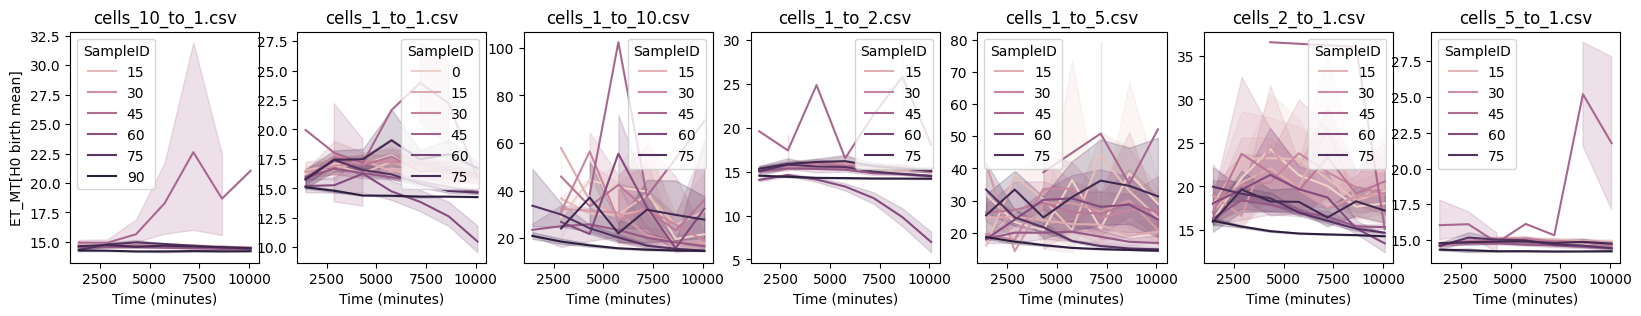

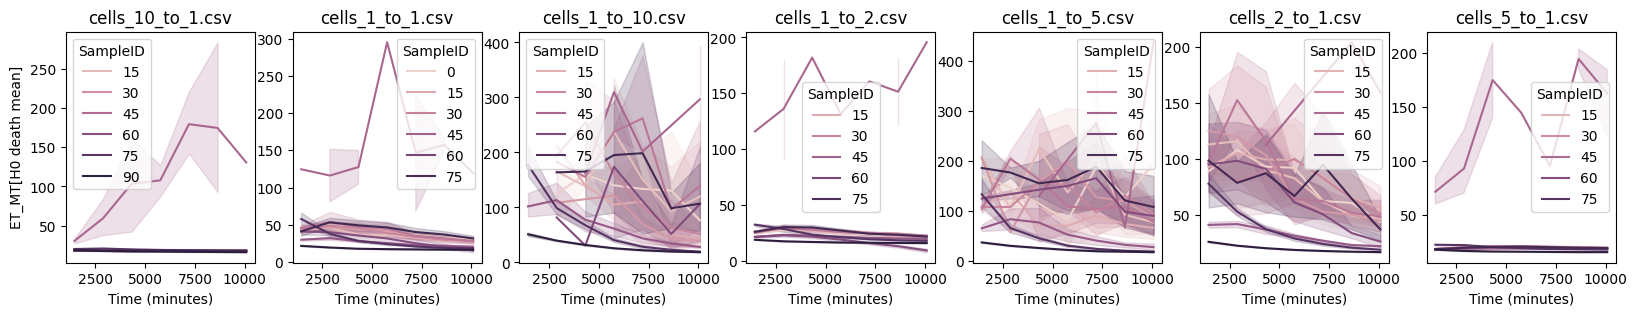

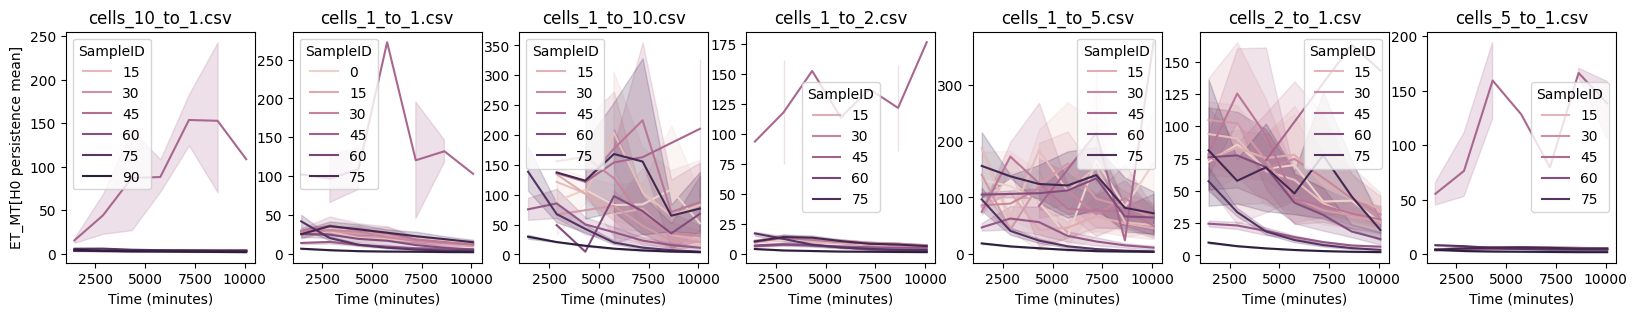

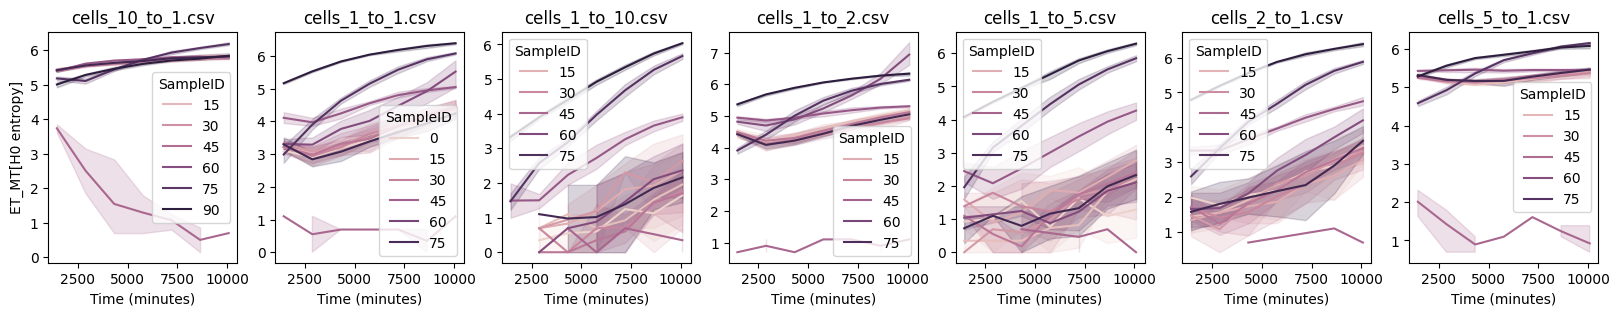

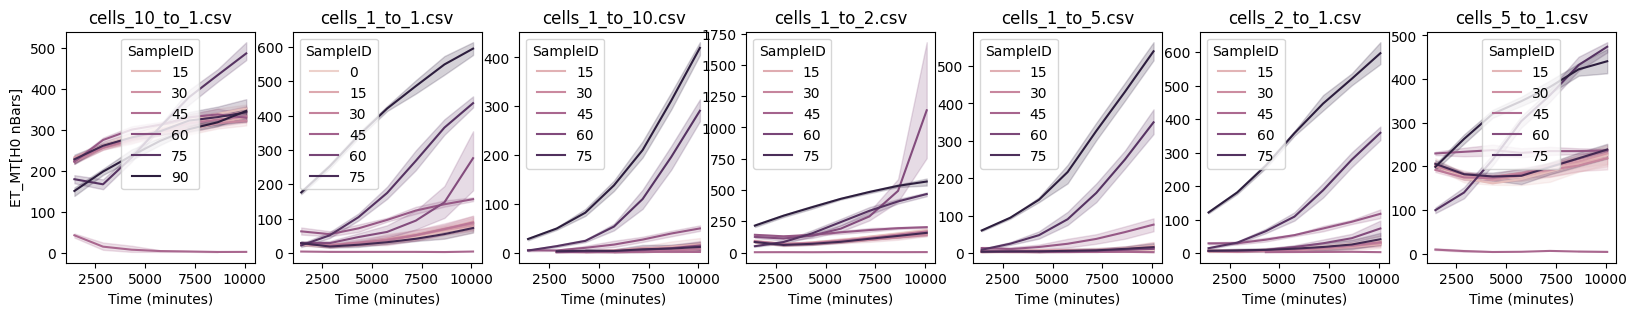

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

qoi_name = 'ET_MT_landmark_witness_pair'
features_ph = ['H0 birth mean', 'H0 death mean', 'H0 persistence mean', 'H0 entropy', 'H0 nBars']
dic_samples_ic = { ic_file: idx_list.tolist() for ic_file, idx_list in df_samples_desc.groupby('IC_file').indices.items()}
for feature_ph in features_ph:
    qoi = f'{qoi_name}[{feature_ph}]'
    fig, axes = plt.subplots(1, len(dic_samples_ic), figsize=(20, 3))
    for id, ic_samples in enumerate(dic_samples_ic.values()):
        df_tda_selected = df_tda[df_tda['SampleID'].isin(ic_samples)]
        sns.lineplot(x='time', y=qoi, hue='SampleID', data=df_tda_selected, ax=axes[id])
        axes[id].set_title(list(dic_samples_ic.keys())[id])
        axes[id].set_xlabel('Time (minutes)')
        if id==0: axes[id].set_ylabel(f'{qoi_name.split("_landmark_witness_pair")[0]}[{feature_ph}]')
        else: axes[id].set_ylabel('')

# Low-dimensional topological state space for tumor–stroma–EMT dynamics

QoIs for each sample, replicate, and snapshot.
- H0 persistence mean
- H0 entropy
- H0 nBars

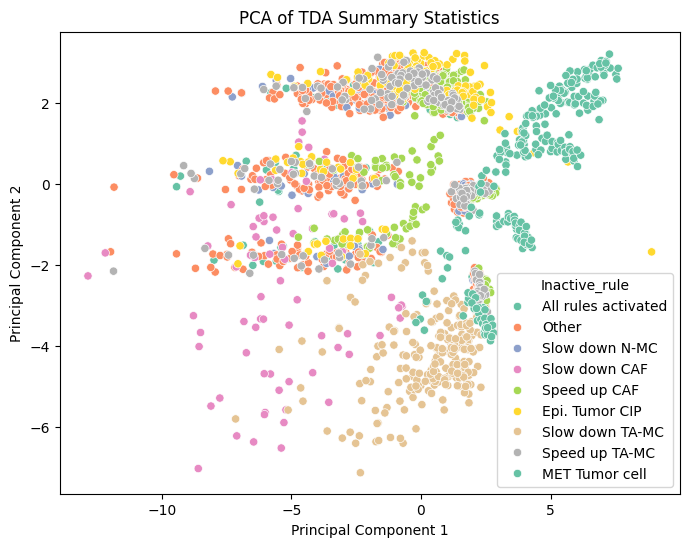

In [4]:
qoi_names_to_pca = [
    'ET_MT_landmark_witness_pair',
    'ET_F_landmark_witness_pair',
    'MT_ET_landmark_witness_pair',
    'MT_F_landmark_witness_pair',
    'F_ET_landmark_witness_pair',
    'F_MT_landmark_witness_pair',
]
features_ph_to_pca = ['H0 persistence mean', 'H0 entropy', 'H0 nBars']
columns_to_pca = [f'{qoi_name}[{feature_ph}]' for qoi_name in qoi_names_to_pca for feature_ph in features_ph_to_pca]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

meta_cols = ['SampleID', 'time', 'ReplicateID']
missing_cols = [c for c in columns_to_pca + meta_cols if c not in df_tda.columns]
if missing_cols:
    raise KeyError(f'Missing columns required for PCA: {missing_cols}')

# Keep only rows with complete PH features for PCA.
mask = df_tda[columns_to_pca].notna().all(axis=1)
df_selected_with_ref = df_tda.loc[mask, columns_to_pca + meta_cols].copy()

if df_selected_with_ref.empty:
    raise ValueError('No complete rows available for PCA after filtering NaNs in PH features.')

# Fit PCA on the exact same rows used in df_selected_with_ref.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected_with_ref[columns_to_pca])
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_scaled)

# Safe alignment: assign PC scores directly by row order.
df_selected_with_ref[['PC1', 'PC2']] = Z_pca

# Map IC_file and Inactive_rule by SampleID index from df_samples_desc.
sample_to_ic = df_samples_desc['IC_file'].to_dict()
sample_to_rule = df_samples_desc['Inactive_rule'].to_dict()
df_selected_with_ref['IC_file'] = df_selected_with_ref['SampleID'].map(sample_to_ic)
df_selected_with_ref['Inactive_rule'] = df_selected_with_ref['SampleID'].map(sample_to_rule)
# Fill any missing Inactive_rule with 'All rules activated'
df_selected_with_ref['Inactive_rule'] = df_selected_with_ref['Inactive_rule'].fillna('All rules activated')
# Remove rules not relevant Others
rules_non_relevant = ['Epi. Normal CIP', 'EMT Normal cell', 'Slown down N-MC', 'Speed up N-MC', 'MET Normal cell']
df_selected_with_ref['Inactive_rule'] = df_selected_with_ref['Inactive_rule'].apply(lambda x: x if x not in rules_non_relevant else 'Other')

# Defensive check: PCA table should not contain NaN in the selected PH feature columns.
if df_selected_with_ref[columns_to_pca].isna().any().any():
    raise RuntimeError('Unexpected NaNs in PCA features after filtering; check input preprocessing.')

# Visualize PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Inactive_rule', data=df_selected_with_ref, palette='Set2')
plt.title('PCA of TDA Summary Statistics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

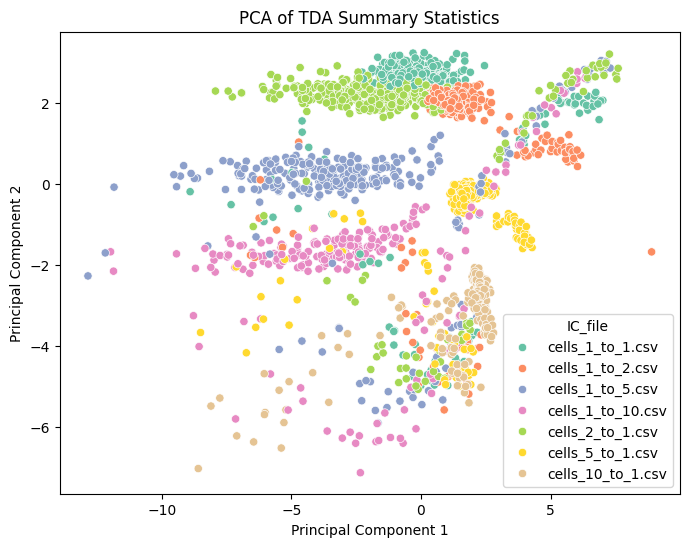

In [5]:
# Visualize PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='IC_file', data=df_selected_with_ref, palette='Set2')
plt.title('PCA of TDA Summary Statistics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

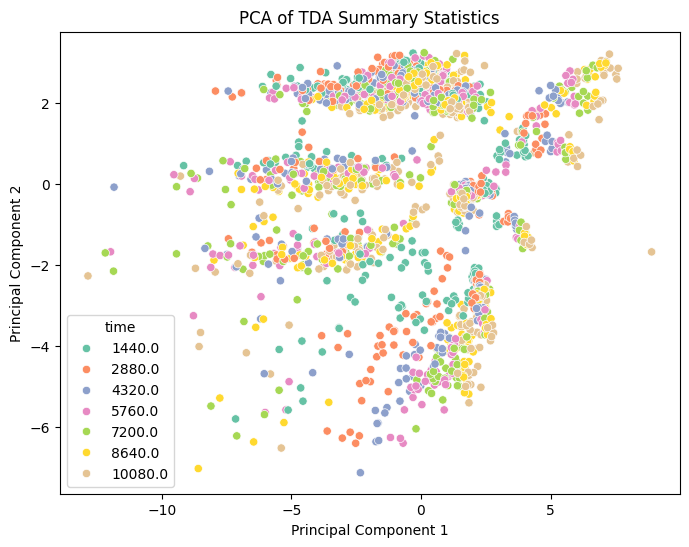

In [6]:
# Visualize PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='time', data=df_selected_with_ref, palette='Set2')
plt.title('PCA of TDA Summary Statistics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Interpretation of the principal components

Loadings represent the contribution of each original feature (TDA summary statistic) to the principal components.
- A high positive loading means that the feature contributes strongly and positively to that PC.
- A high negative loading means it contributes strongly but in the opposite direction.

By examining the loadings, we can identify which TDA summary statistics are most influential in defining the patterns captured by PC1 and PC2, and thus gain insights into the underlying biological processes that differentiate the samples along these principal components.

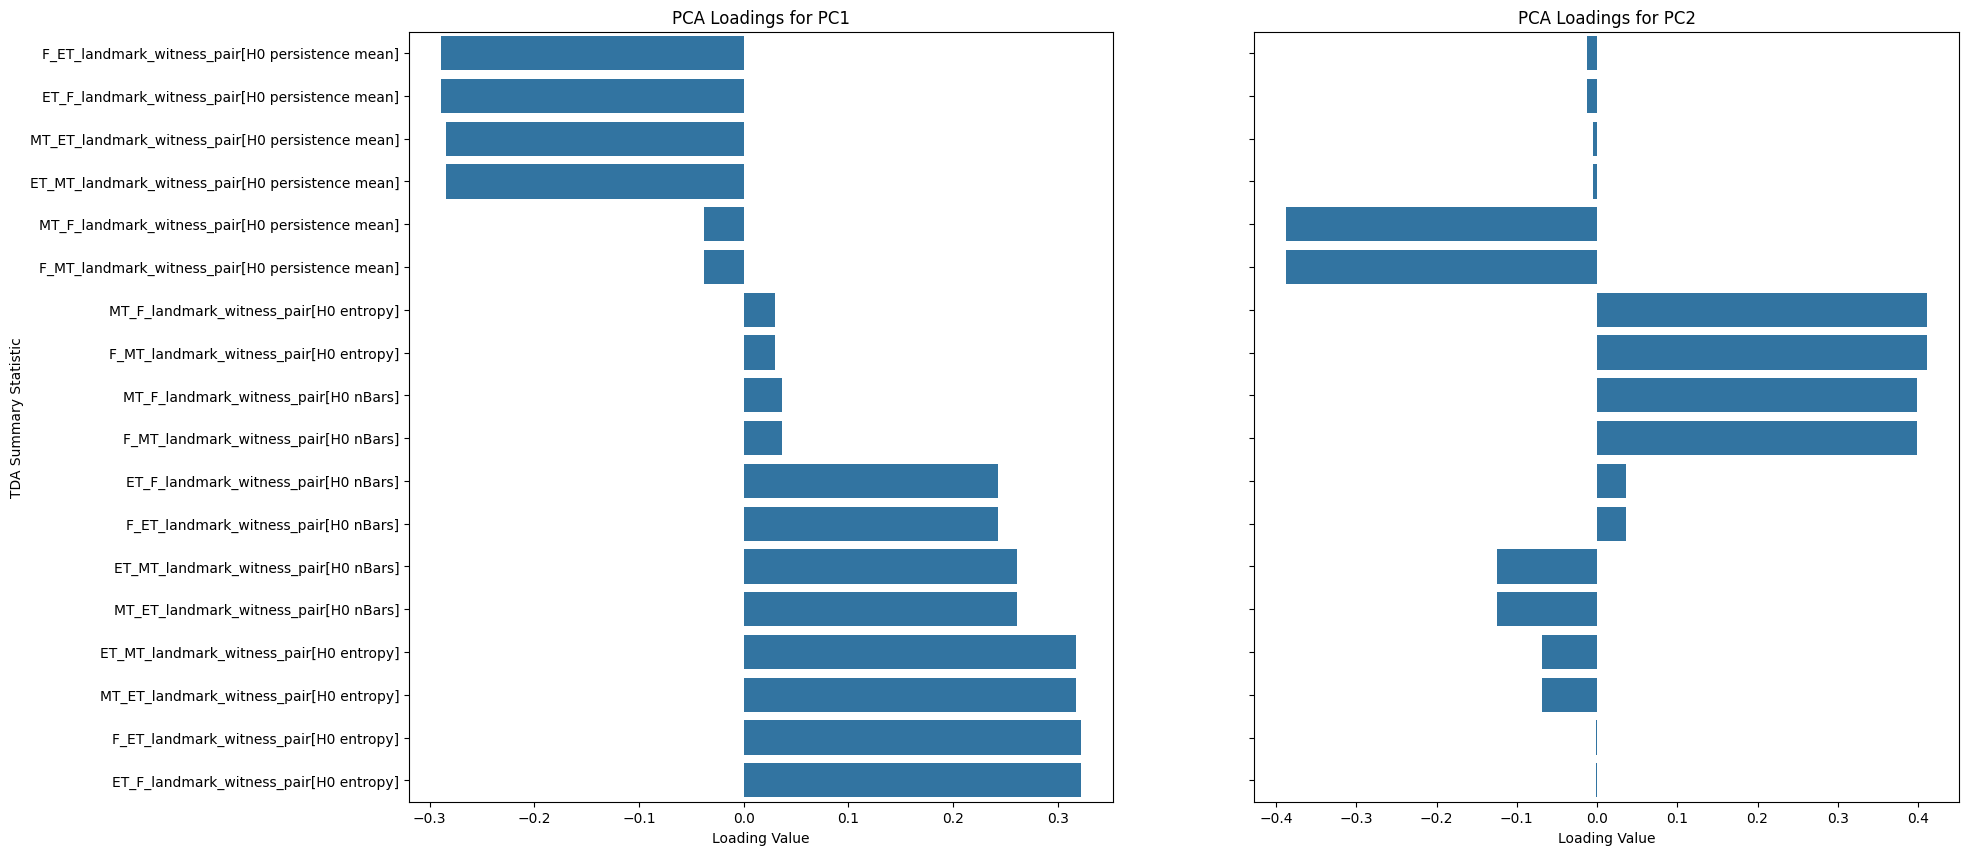

In [7]:
loadings_pc1 = pd.Series(
    pca.components_[0],
    index=columns_to_pca
).sort_values()
loadings_pc2 = pd.Series(
    pca.components_[1],
    index=columns_to_pca
).sort_values()
# Visualize PCA loadings for PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
sns.barplot(x=loadings_pc1.values, y=loadings_pc1.index, ax=axes[0])
sns.barplot(x=loadings_pc2.values, y=loadings_pc2.index, ax=axes[1])
axes[0].set_title('PCA Loadings for PC1')
axes[1].set_title('PCA Loadings for PC2')
axes[0].set_xlabel('Loading Value')
axes[1].set_xlabel('Loading Value')
axes[0].set_ylabel('TDA Summary Statistic')
axes[1].set_ylabel('TDA Summary Statistic')
plt.show()

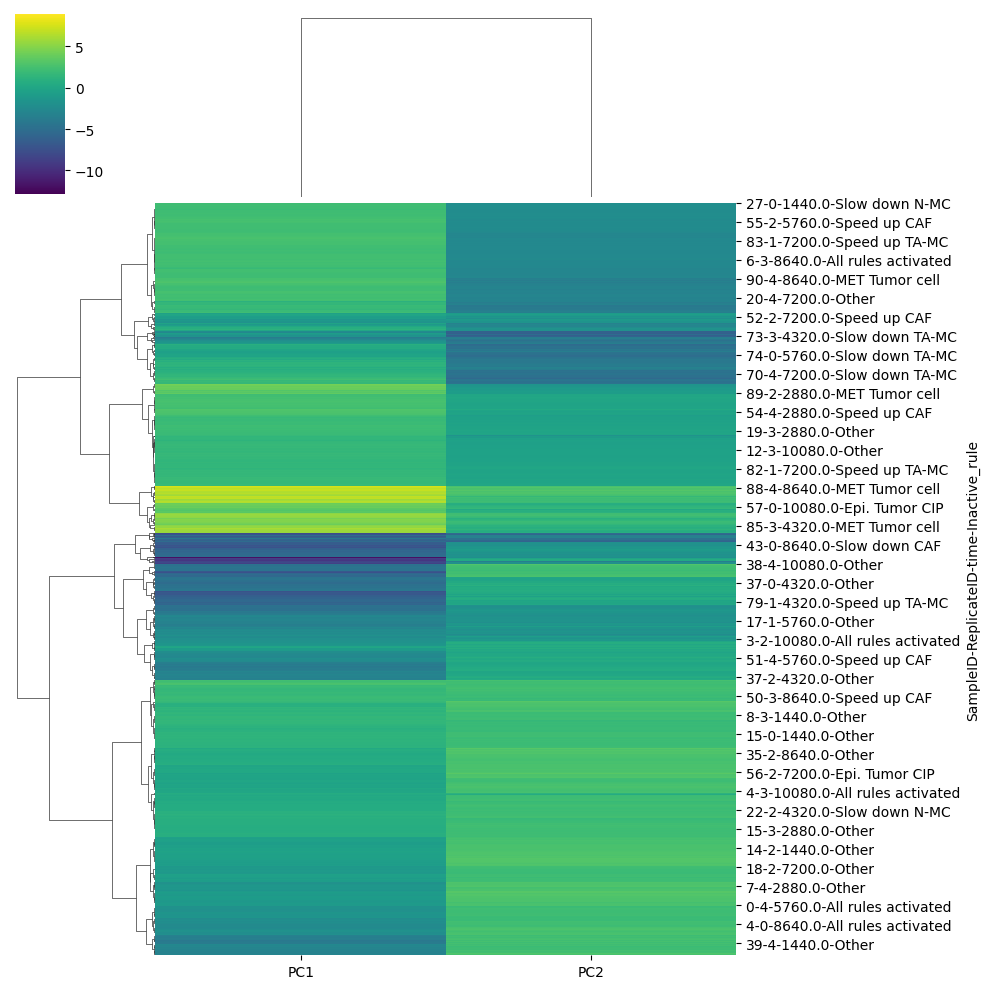

In [8]:
df_plot = df_selected_with_ref[['PC1', 'PC2', 'SampleID', 'ReplicateID', 'time', 'Inactive_rule']].copy()
df_plot = df_plot.set_index(['SampleID', 'ReplicateID', 'time', 'Inactive_rule'])[['PC1', 'PC2']]
sns.clustermap(df_plot, metric='euclidean', method='ward', cmap='viridis')
